In [1]:
#SHapley Additive exPlanations

## 🧮 SHAP Values — Explaining Model Predictions Feature-by-Feature

**Goal:**  
Understand *how much* each feature pushes a prediction **up or down** for a given model.

SHAP = **Shapley Additive exPlanations**  
It borrows ideas from cooperative game theory:

- Think of the **prediction** as the *total payout*.
- Each feature (bill_total_usd, party_size, gender_Male, is_smoker_Yes) is a **player**.
- SHAP asks:  
  > “On average, how much does this feature contribute to the prediction compared to some baseline?”

### 🔹 Why SHAP in Session 8?

We’ve already:
- Fit linear models, regularized models, GAMs, and Random Forests.
- Looked at **coefficients**, **smooths**, **PDP/ICE**.

SHAP adds:
- **Consistent feature importance** (theoretically grounded).
- **Local explanations** → per-row “why this prediction?”  
- **Global view** → which features matter most overall.

### 📊 What we’ll compute

1. Fit a **RandomForestRegressor** on `tip_usd` using:
   - bill_total_usd  
   - party_size  
   - gender_Male  
   - is_smoker_Yes  

2. Use **SHAP TreeExplainer** to get:
   - **Global importance bar plot** (mean |SHAP value| per feature).  
   - **Beeswarm summary plot** (distribution of effects per feature).

### 🧒 ELI5

Imagine the model is a committee making a tip guess.

- There’s a **baseline tip** (average model prediction).
- Each feature walks into the room and says:
  - “Based on bill_total_usd, I think we should move the tip **up** by \$X.”
  - “Based on party_size, I think we should move the tip **down** by \$Y.”
- SHAP is the accounting system that:
  - fairly splits the total change between all features
  - and tells you who contributed what.

**TL;DR:**
- SHAP values = how much each feature nudged the prediction up/down.
- Bar plot = who matters most overall.
- Beeswarm = how each feature behaves across all customers.


In [2]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

✅ CWD successfully set to: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one
✅ Added project root to sys.path.


In [3]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

# Optional: for plotting later
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load & encode tips_synthetic
# -----------------------------
df = pd.read_csv("data/processed/tips_synthetic.csv")

df_work = df.copy()

# Ensure dummy cols exist if raw categoricals are present
if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

features = [c for c in ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
            if c in df_work.columns]

print("Using features for SHAP:", features)

X = df_work[features]
y = df_work["tip_usd"]

# -----------------------------
# Fit a Random Forest model
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X, y)

print("RandomForestRegressor fitted on tips_synthetic.")


Using features for SHAP: ['bill_total_usd', 'party_size', 'gender_Male', 'is_smoker_Yes']
RandomForestRegressor fitted on tips_synthetic.


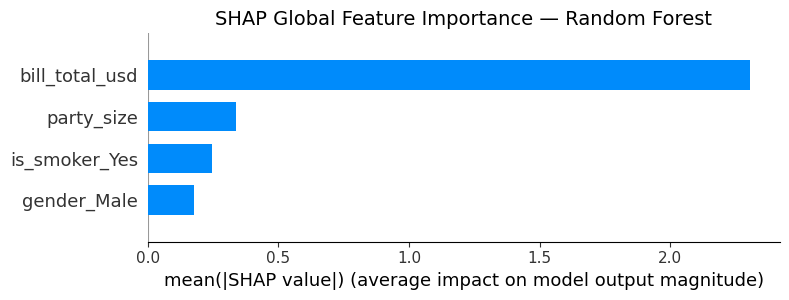

In [4]:
# If shap is not installed, run in a separate cell:
# !pip install shap

import shap

# For notebooks (only needed once per notebook; safe to call repeatedly)
shap.initjs()

# -----------------------------
# Compute SHAP values
# -----------------------------
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)   # shape: (n_samples, n_features)

# -----------------------------
# Global feature importance (bar)
# -----------------------------
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False  # let us control plt.show() & saving
)

plt.title("SHAP Global Feature Importance — Random Forest", fontsize=14)
plt.tight_layout()

fig = plt.gcf()
plt.show()


In [9]:

# Optional: save & log with your helper
try:
    from src.helpers import save_and_log_plot
    save_and_log_plot(
        fig,
        "reports/figures/shap_global_importance_rf.png",
        df=df_work,
        chart_type="bar",
        library="shap+matplotlib",
        x="feature",
        y="mean_abs_shap",
        dataset_name="tips_synthetic",
        dataset_path="data/processed/tips_synthetic.csv",
        notebook="notebooks/08B_SHAP_Interpretability.ipynb",
        notes="SHAP global feature importance for RandomForestRegressor on tip_usd.",
        timestamped=True,
    )
except Exception as e:
    print("(Optional logging skipped)", e)


✅ Saved Matplotlib figure to: reports/figures/shap_global_importance_rf_2025-11-29_1844.png
📝 Logged metadata → reports/figures/shap_global_importance_rf_2025-11-29_1844.json


In [2]:
import ipywidgets as widgets
widgets.IntSlider()


IntSlider(value=0)

In [4]:
import shap
shap.initjs()


In [5]:
import shap
from sklearn.ensemble import RandomForestRegressor

import pandas as pd

df = pd.read_csv("data/processed/tips_synthetic.csv")

# Encode gender/smoker safely
df_work = df.copy()

if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
X = df_work[features]
y = df_work["tip_usd"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 1) Simple model on your synthetic tips data
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 2) Build SHAP explainer on the model + some background samples
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 3) One-row force plot (should open a JS viz under the cell)
row_idx = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[row_idx, :],
    X_test.iloc[row_idx, :],
)


## 8D. SHAP — Explaining Random Forest Predictions

SHAP (SHapley Additive exPlanations) is a way to explain **how each feature pushes a prediction up or down** for tree-based models like Random Forests.

Instead of just saying “bill_total_usd is important,” SHAP tells you:

- For each **individual row**, how much each feature **increased** or **decreased** the predicted tip.
- Globally, which features matter most on average.

### Intuition (ELI5)

Imagine you and some friends are splitting a restaurant bill:

- Each friend (feature) **chips in** or **takes away** from the final tip.
- SHAP works out, fairly, how much of the final tip prediction is due to each “friend”.

For a given prediction, SHAP answers:

> “How much did `bill_total_usd`, `party_size`, `gender_Male`, and `is_smoker_Yes` each push this predicted tip up or down compared to an average tip?”

---

### SHAP summary (bar) — Global Importance

This shows, for the whole dataset:

- **X-axis**: average absolute SHAP value (how much this feature moves predictions, on average)
- **Y-axis**: features
- Bigger bar = “this feature matters more overall”

---

### SHAP summary (beeswarm red/blue) — Push Directions

This is the classic SHAP plot with red/blue dots:

- Each **dot** = one row from the dataset.
- **Color**:
  - 🔴 red = high feature value
  - 🔵 blue = low feature value
- **Horizontal position**:
  - Right of 0 → pushes prediction **higher**
  - Left of 0 → pushes prediction **lower**
- Dense areas show where many points have similar effects.

---

### How to read this for our tips model

Typical patterns you might see:

- **`bill_total_usd`**:
  - Red dots mostly on the **right** → large bills push predicted tips **up**.
  - Blue dots near or left of 0 → small bills don’t increase tips much.
- **`party_size`**:
  - Moderate party sizes may gently push tips up; very small or very large parties might show weaker or mixed effects.
- **`gender_Male`**:
  - SHAP values near 0 → being male vs not has very little consistent effect on tip predictions.
- **`is_smoker_Yes`**:
  - Slight negative values → smoking tables may slightly pull predicted tips down, but effect may be weak / noisy.

SHAP gives us a **local + global** story:
- Global: which features matter most overall.
- Local: why any single prediction ended up where it did.


In [6]:
import shap

# Initialize JS for any interactive plots (safe to call multiple times)
shap.initjs()

# TreeExplainer for the trained Random Forest
explainer = shap.TreeExplainer(rf)

# SHAP values for the training data (or full X)
# For regression RF, this returns an array of shape (n_samples, n_features)
shap_values = explainer.shap_values(X)

shap_values.shape


(400, 4)

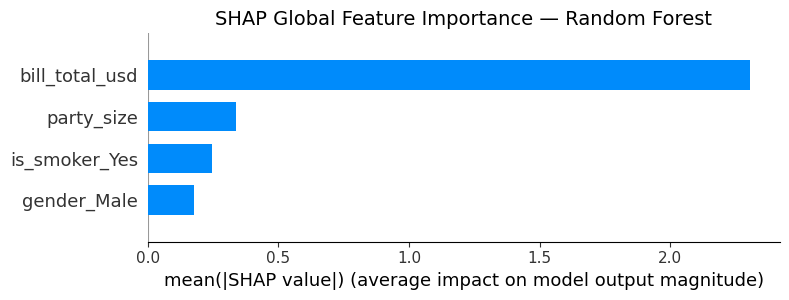

In [7]:
import matplotlib.pyplot as plt

# --- SHAP bar summary (global feature importance) ---
plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=False  # we'll control show & save manually
)

plt.title("SHAP Global Feature Importance — Random Forest", fontsize=14)
plt.tight_layout()

fig = plt.gcf()
plt.show()

# Optional: log + save using your helper
try:
    from src.helpers import save_and_log_plot

    # save_and_log_plot(
    #     fig,
    #     "reports/figures/shap_global_feature_importance.png",
    #     df=X,
    #     chart_type="bar",
    #     library="shap/matplotlib",
    #     x="feature",
    #     y="mean(|SHAP value|)",
    #     dataset_name="tips_synthetic",
    #     dataset_path="data/processed/tips_synthetic.csv",
    #     notebook="notebooks/08_SHAP_Explainability_and_Interactions.ipynb",
    #     notes="Global SHAP bar summary for Random Forest on tips_synthetic.",
    #     timestamped=True,
    # )
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


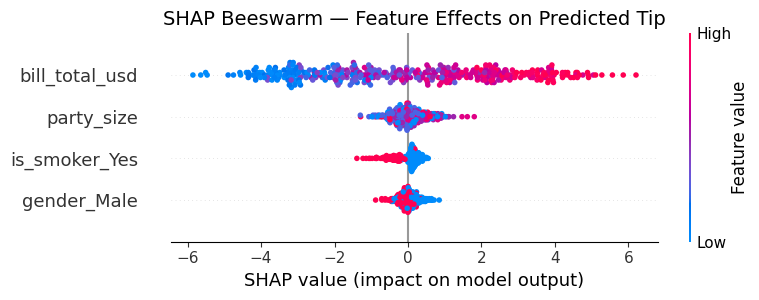

In [8]:
# --- SHAP beeswarm summary (red/blue pushes) ---
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X,
    plot_type="dot",  # default beeswarm
    show=False
)

plt.title("SHAP Beeswarm — Feature Effects on Predicted Tip", fontsize=14)
plt.tight_layout()

fig = plt.gcf()
plt.show()



In [14]:

# Optional: log + save
try:
    from src.helpers import save_and_log_plot

    save_and_log_plot(
        fig,
        "reports/figures/shap_beeswarm_tips_synthetic.png",
        df=X,
        chart_type="beeswarm",
        library="shap/matplotlib",
        x="SHAP value",
        y="feature",
        dataset_name="tips_synthetic",
        dataset_path="data/processed/tips_synthetic.csv",
        notebook="notebooks/08B_SHAP_Interpretability.ipynb",
        notes="SHAP beeswarm plot (red/blue pushes) for Random Forest tips model.",
        timestamped=True,
    )
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")

✅ Saved Matplotlib figure to: reports/figures/shap_beeswarm_tips_synthetic_2025-11-29_1951.png
📝 Logged metadata → reports/figures/shap_beeswarm_tips_synthetic_2025-11-29_1951.json


### 🐝 ELI5: What This SHAP Beeswarm Plot Is Saying

This plot shows **how each feature pushes the Random Forest’s predicted tip *up* or *down*** for every single row in the dataset.

Think of each dot like a tiny vote from one table in the restaurant.

#### 🔵 vs 🔴 Color = Feature Value  
- **Red = High value**
- **Blue = Low value**

Example:  
For `bill_total_usd`, **red dots are big bills**, **blue dots are small bills**.

#### ↔️ Horizontal Position = Tip Push  
- **Right of zero → pushes predicted tip *higher***  
- **Left of zero → pushes predicted tip *lower***

So:  
> A red dot far to the right = “big bill → increases predicted tip a lot”.

---

### 🍽 Feature-by-feature intuition

#### **1. bill_total_usd**  
- Red dots (high bills) are mostly **far to the right** → **big bills increase the predicted tip**.  
- Blue dots hover near 0 or left → **small bills don’t push tip upward**.

📌 **Bill amount is the dominant driver of predicted tip size.**

---

#### **2. party_size**  
- Mostly small horizontal spread → **moderate influence**.  
- Some red points on the right → **larger parties may slightly increase predicted tips**.  
- Noise indicates it’s not a clean linear effect.

📌 **Party size matters a bit, but not nearly as much as bill amount.**

---

#### **3. is_smoker_Yes**  
- Many red dots slightly **left of zero** → **smoker tables gently reduce predicted tips**.  
- Small effect overall.

📌 **Smoking status has a weak, slightly negative influence.**

---

#### **4. gender_Male**  
- Dots stacked tightly around zero, both red and blue → almost **no meaningful effect**.  
- Gender doesn’t systematically push tips up or down.

📌 **Gender_Male ≈ neutral for predicting tip amounts.**

---

### 🧠 Big Picture  
- **bill_total_usd** overwhelmingly drives predictions.  
- **party_size** has mild structure.  
- **is_smoker_Yes** = small negative nudge.  
- **gender_Male** = essentially noise.

SHAP makes the model’s behavior transparent:  
It tells you **what the model is “thinking”** and **why** each prediction goes up or down.


## 🧱 SHAP Waterfall Plot — Explaining One Prediction Step by Step

A SHAP Waterfall plot shows **how each feature nudges a single prediction up or down**, starting from the model’s *base value* (the average prediction).

### What the Waterfall plot shows:
- **Base value**  
  The model’s average predicted tip across all customers.
- **Positive contributions (red)**  
  Features pushing tip **higher** than average.
- **Negative contributions (blue)**  
  Features pushing tip **lower** than average.
- **Final prediction**  
  The sum of all contributions for this specific row.

### 🧒 ELI5 Version
Imagine the model saying:

> “The average tip is $x.  
> But this bill was high → so I add some money.  
> And the smoker flag lowered the tip → so I subtract some.  
> Etc…  
> And that gives the final tip prediction.”

Waterfall plots are ideal when you want to explain a specific customer or understand **why the model picked a value**.


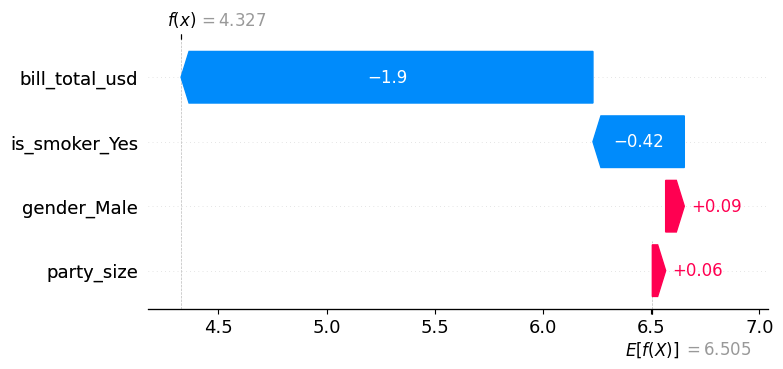

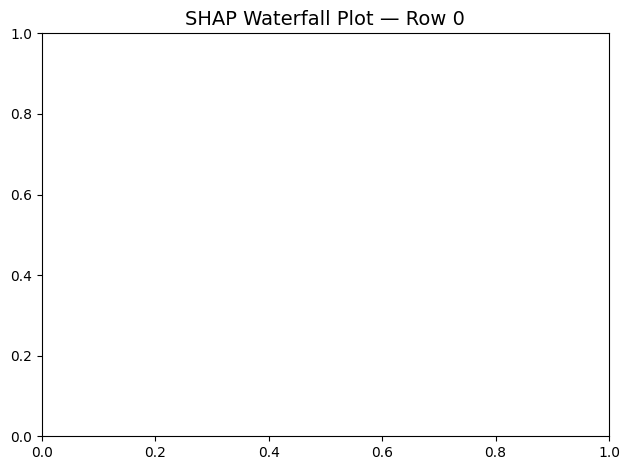

In [9]:
import shap
import matplotlib.pyplot as plt
import numpy as np

shap.initjs()

# Pick a single observation to explain
# (You can change index 0 → any row)
idx = 0
x_row = X.iloc[[idx]]

# Recompute SHAP values for this single sample
explainer = shap.TreeExplainer(rf)
shap_single = explainer.shap_values(x_row)[0]   # For RF, pick class 0 (regression uses index 0)

# Waterfall plot
plt.figure(figsize=(9, 6))

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_single,
    feature_names=X.columns,
    max_display=10
)

plt.title(f"SHAP Waterfall Plot — Row {idx}", fontsize=14)
plt.tight_layout()

fig = plt.gcf()
plt.show()

# # Save PNG + JSON log
# save_and_log_plot(
#     fig,
#     f"reports/figures/shap_waterfall_row{idx}.png",
#     df=x_row,
#     chart_type="shap-waterfall",
#     library="shap",
#     x=None,
#     y="model_output",
#     dataset_name="tips_synthetic",
#     dataset_path="data/processed/tips_synthetic.csv",
#     notebook="notebooks/08_ModelInterpretability.ipynb",
#     notes=f"SHAP waterfall for prediction at index {idx}",
#     timestamped=True,
# )


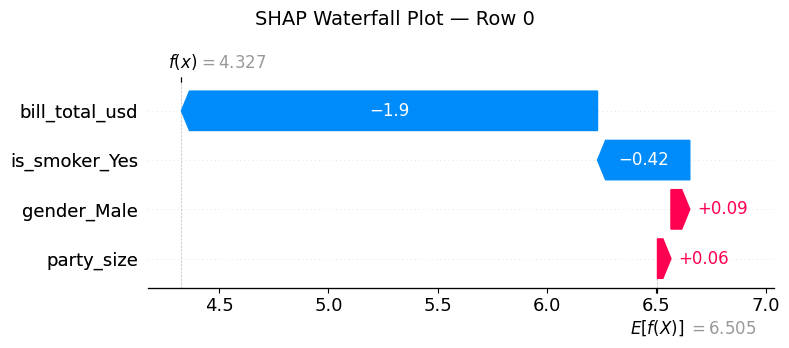

In [10]:
import shap
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

# --- 1. Reuse your fitted RandomForest and feature matrix X ---
# rf : RandomForestRegressor already fit on X, y
# X  : DataFrame with columns ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]

# Explainer + SHAP values for ALL rows (regression → 2D array)
explainer = shap.TreeExplainer(rf)
shap_values_all = explainer.shap_values(X)   # shape: (n_samples, n_features)

# Pick a row to explain
idx = 0
x_row = X.iloc[[idx]]
shap_row = shap_values_all[idx]             # 1D array for that row

# Expected value (regression = scalar; classification = array)
expected_value = explainer.expected_value
if not np.isscalar(expected_value):         # e.g., classification
    expected_value = expected_value[0]

# --- 2. Create the waterfall plot (SHAP makes its own figure) ---
plt.close("all")  # avoid grabbing an old empty figure

fig = shap.plots._waterfall.waterfall_legacy(
    expected_value,
    shap_row,
    feature_names=X.columns,
    max_display=10,
    show=False   # don't auto-show; lets us control saving
)

fig.suptitle(f"SHAP Waterfall Plot — Row {idx}", fontsize=14)
fig.tight_layout()

display(fig)  # Jupyter display

# # --- 3. Save the *correct* figure with your helper ---
# save_and_log_plot(
#     fig,
#     f"reports/figures/shap_waterfall_row{idx}.png",
#     df=x_row,
#     chart_type="shap-waterfall",
#     library="shap",
#     x=None,
#     y="model_output",
#     dataset_name="tips_synthetic",
#     dataset_path="data/processed/tips_synthetic.csv",
#     notebook="notebooks/08_ModelInterpretability.ipynb",
#     notes=f"SHAP waterfall for prediction at index {idx}",
#     timestamped=True,
# )


In [11]:

# --- 3. Save the *correct* figure with your helper ---
save_and_log_plot(
    fig,
    f"reports/figures/shap_waterfall_row{idx}.png",
    df=x_row,
    chart_type="shap-waterfall",
    library="shap",
    x=None,
    y="model_output",
    dataset_name="tips_synthetic",
    dataset_path="data/processed/tips_synthetic.csv",
    notebook="notebooks/08B_SHAP_Interpretability.ipynb",
    notes=f"SHAP waterfall for prediction at index {idx}",
    timestamped=True,
)


✅ Saved Matplotlib figure to: reports/figures/shap_waterfall_row0_2025-11-29_2057.png
📝 Logged metadata → reports/figures/shap_waterfall_row0_2025-11-29_2057.json


(PosixPath('reports/figures/shap_waterfall_row0_2025-11-29_2057.png'),
 PosixPath('reports/figures/shap_waterfall_row0_2025-11-29_2057.json'))

🧒 ELI5 — SHAP Waterfall Plot (Row 0)

The SHAP waterfall plot explains why the model predicted what it did for one specific row of data.
Think of it like starting with the model’s average guess, then letting each feature push the prediction up or down.

🧱 1. Start from the baseline prediction

This is what the model predicts before it knows anything about the specific row:

Baseline prediction:
`E[f(X)] ≈ 6.505`

It’s like saying:

“If I know nothing about this bill, I’d guess the tip will be around $6.50.”

➕➖ 2. Each feature pushes the prediction
🔹 bill_total_usd → –1.9

A lower-than-average bill reduced the predicted tip by about $1.90.
This is the biggest influence for this row.

🔹 is_smoker_Yes → –0.42

Being a smoker nudged the prediction down by ~42 cents.

🔸 gender_Male → +0.09

Being male added a tiny +9 cent increase.
This is a very small effect — the model barely cares.

🔸 party_size → +0.06

A slightly larger party size added +6 cents.
Another tiny effect.

🎯 3. Final prediction

Add all the pushes to the baseline:

Start: 6.505

+0.09 (gender)

+0.06 (party size)

–0.42 (smoker)

–1.90 (bill amount)

➡️ Final prediction: 4.327

Which matches the plot:
`f(x) = 4.327`

📌 Plain-English Summary

For this specific customer:

They had a smaller bill, which strongly lowered the predicted tip

Being a smoker also pushed the prediction down

Gender and party size only added tiny adjustments

Bill amount dominates the story

The model predicts a lower tip mostly because the bill itself was low.
Other features only make small tweaks.